In [25]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_cafe_sales.csv to cleaned_cafe_sales (1).csv


In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [31]:
df = pd.read_csv("cleaned_cafe_sales.csv")

df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,08-09-2023
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,16-05-2023
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,19-07-2023
3,TXN_7034554,Salad,2,5.0,10.0,Digital Wallet,Takeaway,27-04-2023
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,11-06-2023


In [32]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset:
(10000, 8)

Columns:
['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']

Missing Values:
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64


In [33]:
df['Transaction Date'] = pd.to_datetime(
    df['Transaction Date'],
    errors='coerce'
)

print(df['Transaction Date'].head())

0   2023-08-09
1          NaT
2          NaT
3          NaT
4   2023-11-06
Name: Transaction Date, dtype: datetime64[ns]


In [34]:
total_revenue = df['Total Spent'].sum()

total_transactions = len(df)

total_items_sold = df['Quantity'].sum()

average_order_value = df['Total Spent'].mean()

print("========== KPI REPORT ==========")

print("Total Revenue :", round(total_revenue,2))

print("Total Transactions :", total_transactions)

print("Total Items Sold :", total_items_sold)

print("Average Order Value :", round(average_order_value,2))

========== KPI REPORT ==========
Total Revenue : 89307.5
Total Transactions : 10000
Total Items Sold : 30271
Average Order Value : 8.93


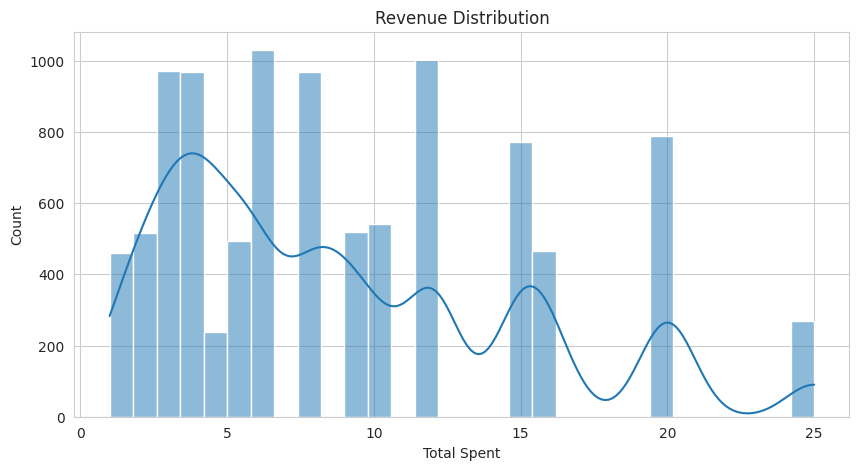

In [35]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Total Spent'],
    bins=30,
    kde=True
)

plt.title("Revenue Distribution")
plt.show()

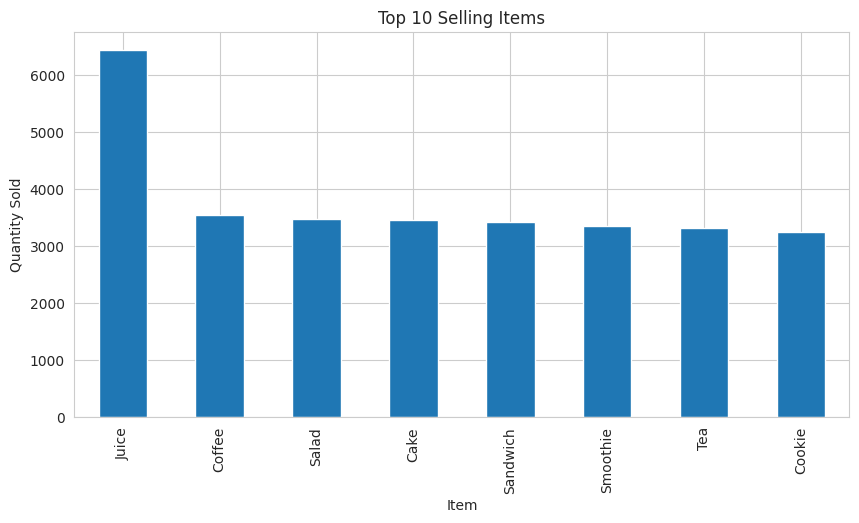

Item
Juice       6435
Coffee      3551
Salad       3469
Cake        3467
Sandwich    3428
Smoothie    3353
Tea         3319
Cookie      3249
Name: Quantity, dtype: int64


In [36]:
top_items = (
    df.groupby('Item')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_items.plot(kind='bar')

plt.title("Top 10 Selling Items")

plt.ylabel("Quantity Sold")

plt.show()

print(top_items)

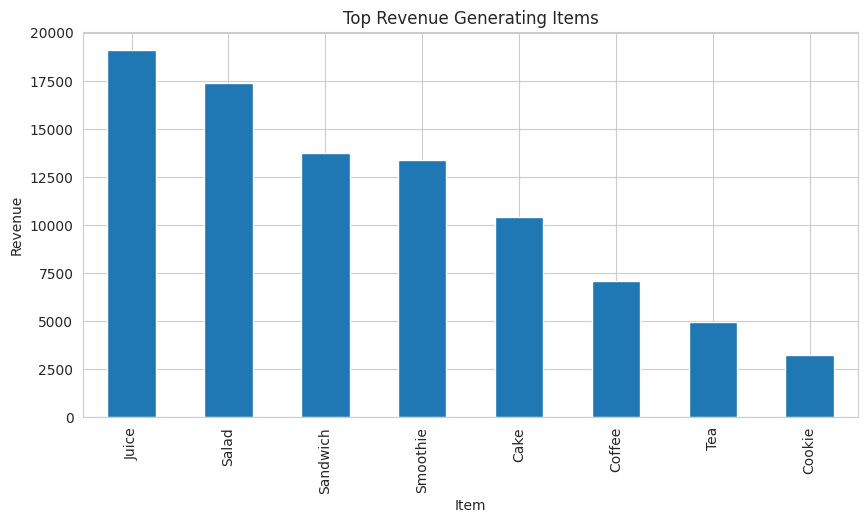

Item
Juice       19079.5
Salad       17365.0
Sandwich    13751.0
Smoothie    13362.0
Cake        10413.0
Coffee       7107.0
Tea          4974.0
Cookie       3256.0
Name: Total Spent, dtype: float64


In [37]:
top_revenue_items = (
    df.groupby('Item')['Total Spent']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_revenue_items.plot(kind='bar')

plt.title("Top Revenue Generating Items")

plt.ylabel("Revenue")

plt.show()

print(top_revenue_items)

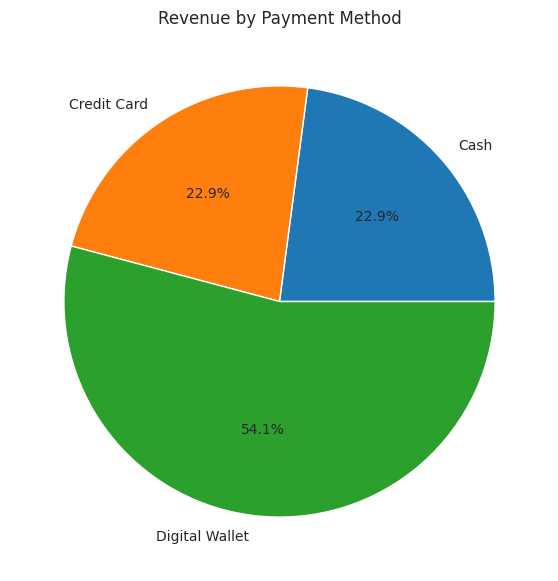

In [38]:
payment_sales = (
    df.groupby('Payment Method')['Total Spent']
    .sum()
)

plt.figure(figsize=(7,7))

payment_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Revenue by Payment Method")

plt.ylabel("")

plt.show()

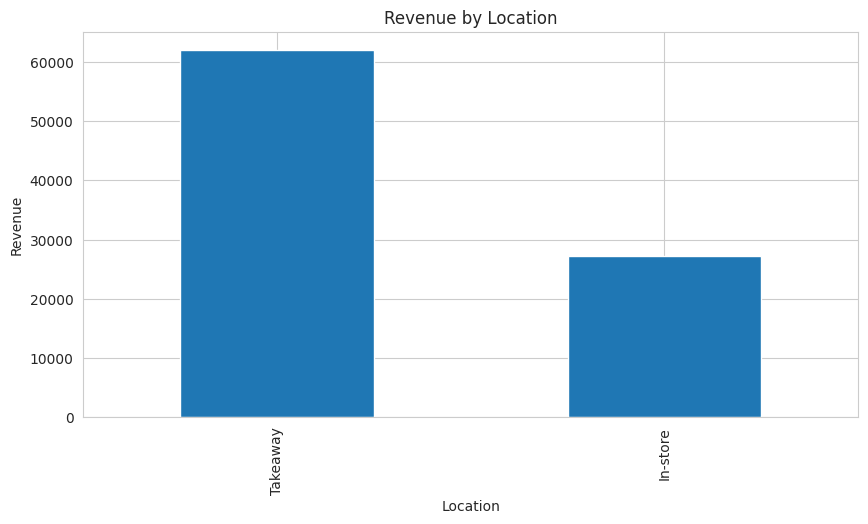

Location
Takeaway    62047.0
In-store    27260.5
Name: Total Spent, dtype: float64


In [39]:
location_sales = (
    df.groupby('Location')['Total Spent']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

location_sales.plot(kind='bar')

plt.title("Revenue by Location")

plt.ylabel("Revenue")

plt.show()

print(location_sales)

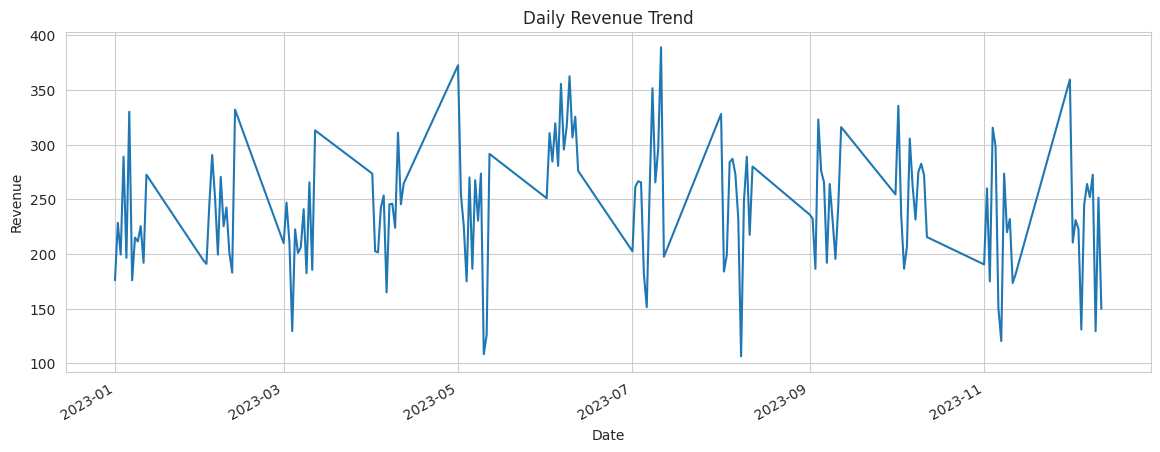

In [40]:
daily_sales = (
    df.groupby('Transaction Date')['Total Spent']
    .sum()
)

plt.figure(figsize=(14,5))

daily_sales.plot()

plt.title("Daily Revenue Trend")

plt.ylabel("Revenue")

plt.xlabel("Date")

plt.show()

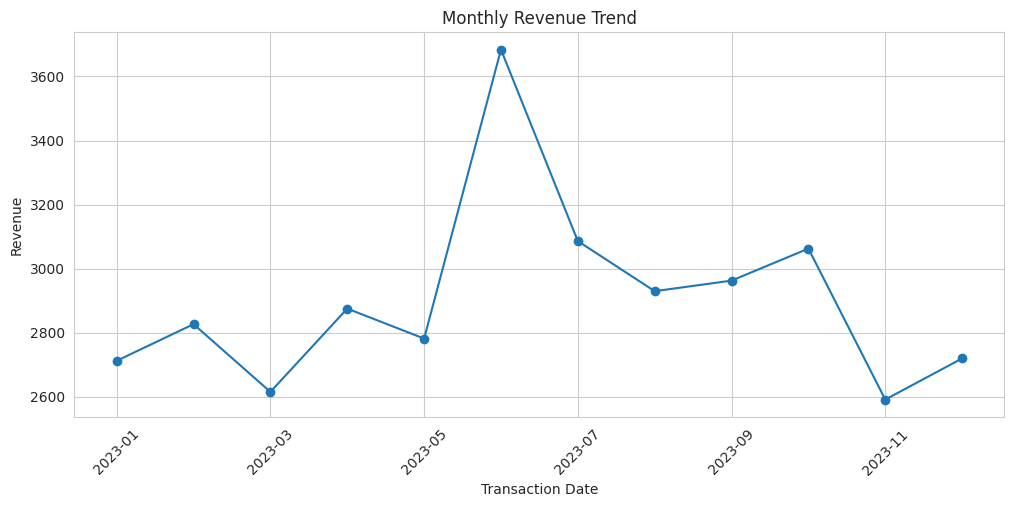

In [41]:
monthly_sales = (
    df.groupby(
        df['Transaction Date'].dt.to_period('M')
    )['Total Spent']
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Revenue Trend")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [42]:
item_analysis = (
    df.groupby('Item')
    .agg({
        'Quantity':'sum',
        'Total Spent':'sum'
    })
)

item_analysis['Revenue Per Item'] = (
    item_analysis['Total Spent']
    /
    item_analysis['Quantity']
)

item_analysis = item_analysis.sort_values(
    by='Total Spent',
    ascending=False
)

item_analysis.head(10)

,Quantity,Total Spent,Revenue Per Item
Item,,,
Juice,6435,19079.5,2.964957
Salad,3469,17365.0,5.005765
Sandwich,3428,13751.0,4.011377
Smoothie,3353,13362.0,3.985088
Cake,3467,10413.0,3.003461
Coffee,3551,7107.0,2.001408
Tea,3319,4974.0,1.498644
Cookie,3249,3256.0,1.002155


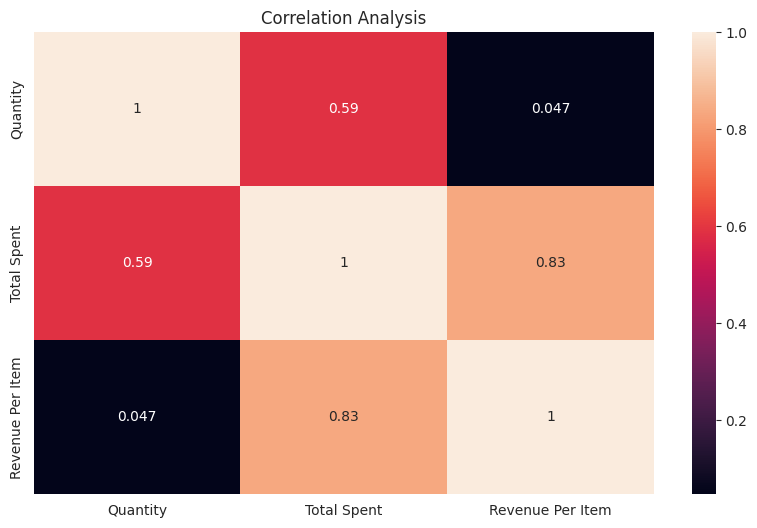

In [43]:
plt.figure(figsize=(10,6))

sns.heatmap(
    item_analysis[['Quantity',
                   'Total Spent',
                   'Revenue Per Item']]
    .corr(),
    annot=True
)

plt.title("Correlation Analysis")

plt.show()

In [44]:
print("BUSINESS INSIGHTS")

print("\n1. Highest Revenue Item:")
print(
    df.groupby('Item')['Total Spent']
    .sum()
    .idxmax()
)

print("\n2. Most Sold Item:")
print(
    df.groupby('Item')['Quantity']
    .sum()
    .idxmax()
)

print("\n3. Best Location:")
print(
    df.groupby('Location')['Total Spent']
    .sum()
    .idxmax()
)

print("\n4. Preferred Payment Method:")
print(
    df.groupby('Payment Method')['Total Spent']
    .sum()
    .idxmax()
)

BUSINESS INSIGHTS

1. Highest Revenue Item:
Juice

2. Most Sold Item:
Juice

3. Best Location:
Takeaway

4. Preferred Payment Method:
Digital Wallet


In [45]:
df.to_csv(
    "Cafe_Sales_Dashboard.csv",
    index=False
)

print("Dashboard dataset saved successfully.")

Dashboard dataset saved successfully.


In [46]:
from google.colab import files

files.download(
    "Cafe_Sales_Dashboard.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>